# Unique Solution of Schochastic Fixed-Point Equation

This notebook is to check conjectures in proving that the SFPE
$$X \stackrel{d}{=} I(U^{\alpha}X^{(1)} + (1-U)^{\alpha}X^{(2)}) + J\max(U^{\alpha}X^{(1)}, (1-U)^{\alpha}X^{(2)})$$

has a unique solution $(\alpha^*, X_{\alpha^*})$ such that $\mathbb{E}[X_{\alpha^*}] = 1$.

The classical contraction method does not work: because of the sum, $W_p$ does not work; because of the max, $\zeta_p$ does not work.

In [2]:
from typing import Literal

import numpy as np
import matplotlib.pyplot as plt

In [5]:
# sage -n jupyter --no-browser

import os, sys
from pathlib import Path

print("Working directory:", os.getcwd())
print("Kernel executable:", sys.executable)

if sys.executable.lower().endswith('sage'):
  target = Path("/mnt/d/Projects/m2-bezout/internship/src/notebooks/")
  os.chdir(target)
  print("Changed working directory to:", os.getcwd())


import importlib

from utils import styled_print

import monte_carlo
importlib.reload(monte_carlo)
from monte_carlo import sample_from_empirical, plot_distribution, pmf_to_particles, MeanOneGenerator, wasserstein

Working directory: /home/stages/chau/projects/m2-bezout/internship/src/local/notebooks
Kernel executable: /home/stages/chau/miniforge3/bin/python


#### Check convergence to an $\alpha$ and unique limit distribution

In [6]:
def apply_T(X, u,v, alpha):
    # Sample independent pairs
    X1 = sample_from_empirical(X)
    X2 = sample_from_empirical(X)
    
    # Sample U, I and J
    U = np.random.uniform(0, 1, size=len(X))
    R = np.random.uniform(0, 1, size=len(X))
    
    I = (R < u).astype(np.float64)
    J = ((R >= u) & (R < u + v)).astype(np.float64)
    
    # Apply the operator T_alpha
    term1 = (U**alpha) * X1
    term2 = ((1 - U)**alpha) * X2
    
    T_X = I * (term1 + term2) + J * np.maximum(term1, term2)

    return T_X

def apply_S(X, u, v, alpha):
    Y = apply_T(X, u, v, alpha)
    return Y / np.mean(Y)

##### Bisection

In [7]:
def cummulative_mean(alpha, u, v, X, burn_in=15, num_iters=40):
    
    multipliers = []
    
    for i in range(burn_in + num_iters):
        Y = apply_T(X, u, v, alpha)
        step_mean = np.mean(Y)

        X = Y / step_mean
                
        # Record the multiplier (ignoring the burn-in period)
        if i >= burn_in:
            multipliers.append(step_mean)
            
    return np.mean(multipliers), X

def find_alpha(u, v, X_init, lower, upper, tolerance=1e-10, max_steps=15):
    """
    Uses bisection search to find the root of cummulative_mean(alpha) = 1.
    """
    print(f"Searching for alpha* for u={u}, v={v}")
    print(f"{'Step':<5} | {'Alpha Estimate':<15} | {'Cumulative Mean':<15}")
    print("-" * 40)
    
    for step in range(max_steps):
        mid_alpha = (lower + upper) / 2.0
        
        # Estimate the growth rate for this alpha
        current_mean, X = cummulative_mean(mid_alpha, u, v, X_init)
        
        print(f"{step+1:<5} | {mid_alpha:<15.5f} | {current_mean:<15.5f}")
        
        # Check for convergence
        if abs(current_mean - 1.0) < tolerance:
            print("-" * 40)
            print(f"Converged! alpha* = {mid_alpha:.5f}")
            return mid_alpha, X
            
        # If current_mean > 1, increase alpha.
        if current_mean > 1.0:
            lower = mid_alpha
        else:
            upper = mid_alpha
            
    print("-" * 40)
    print(f"Reached max steps. Best estimate for alpha* ≈ {mid_alpha:.5f}")
    return mid_alpha, X


/home/stages/chau/projects/m2-bezout/internship/src/local/notebooks/monte_carlo.py:127: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  ax = sns.kdeplot(view_array, fill=True, alpha=0.3, linewidth=2)


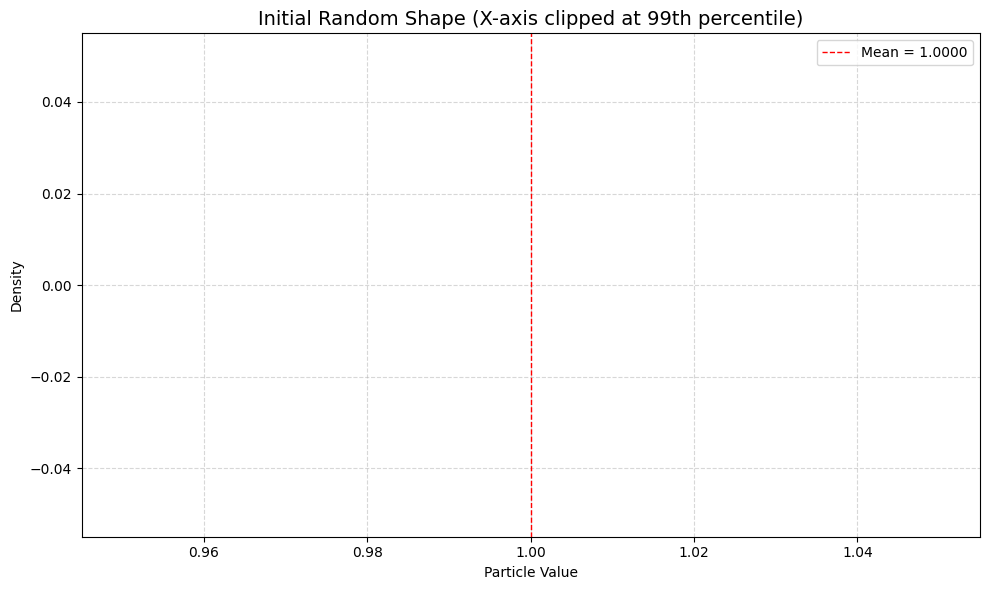

Searching for alpha* for u=0.5, v=0.3
Step  | Alpha Estimate  | Cumulative Mean
----------------------------------------
1     | 0.45000         | 1.01664        
2     | 0.52500         | 0.97173        
3     | 0.48750         | 0.99355        
4     | 0.46875         | 1.00508        
5     | 0.47813         | 0.99891        
6     | 0.47344         | 1.00205        
7     | 0.47578         | 1.00063        
8     | 0.47695         | 0.99995        
9     | 0.47637         | 1.00036        
10    | 0.47666         | 1.00018        
11    | 0.47681         | 1.00009        
12    | 0.47688         | 1.00004        
13    | 0.47692         | 0.99999        
14    | 0.47690         | 1.00008        
15    | 0.47691         | 0.99990        
16    | 0.47690         | 0.99989        
17    | 0.47690         | 1.00013        
18    | 0.47690         | 0.99986        
19    | 0.47690         | 0.99996        
20    | 0.47690         | 0.99996        
---------------------------------------

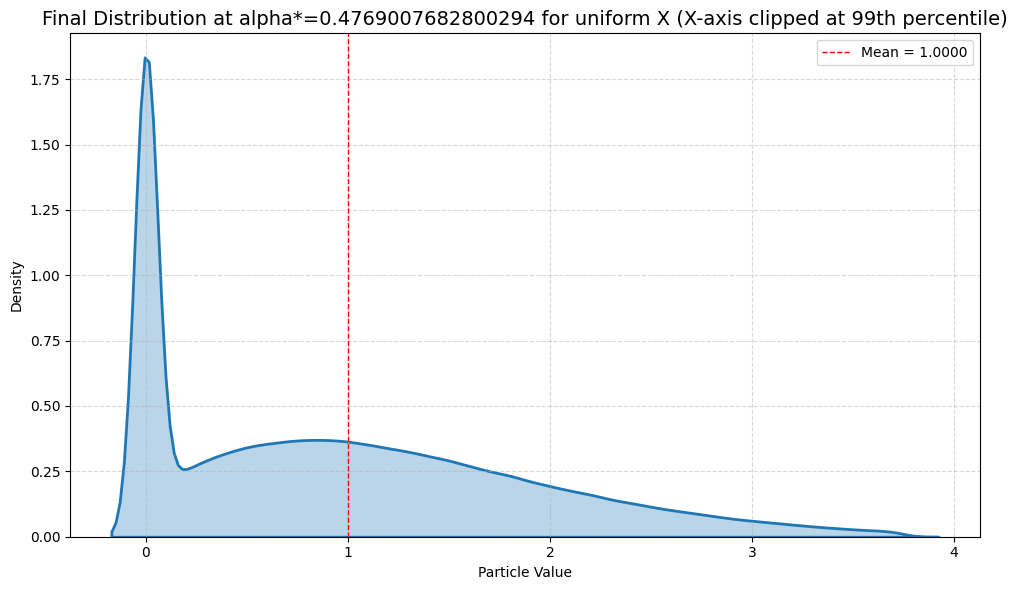

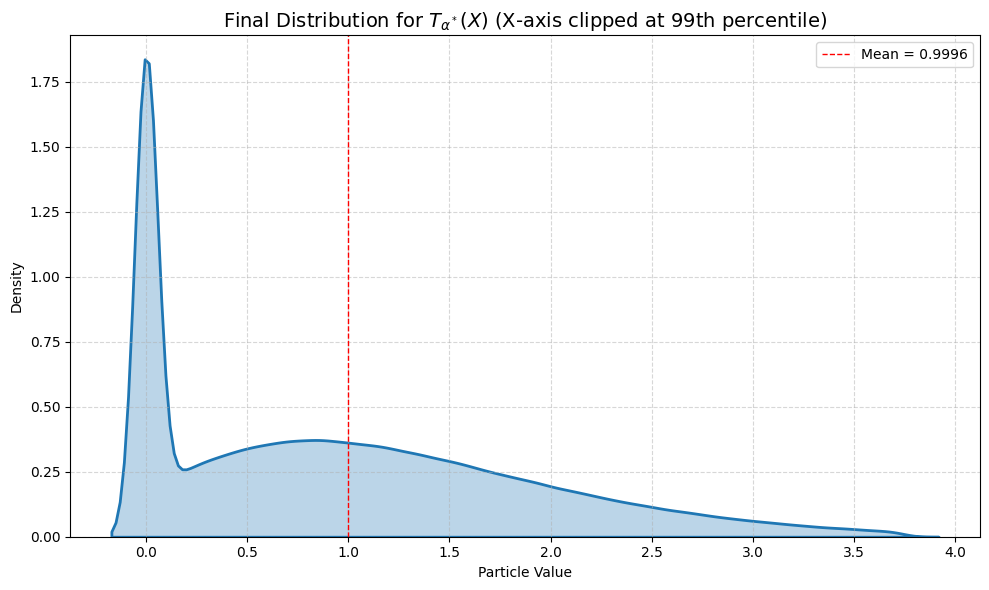

In [ ]:
generator = MeanOneGenerator(size=1000000)
X_init,_,_ = generator.generate_custom_shape('dirac')
plot_distribution(X_init, title="Initial Random Shape", clip_percentile=99)

u, v = 0.5, 0.3

lower = 2*u + v - 1
upper  = 2*(u+v) - 1

alpha_star, X_final = find_alpha(u, v, X_init, lower=lower, upper=upper, max_steps=20)
T_X_final = apply_T(X_final, u, v, alpha_star)

print(f"Final alpha*: {alpha_star}")
print(f"W1 distance between X_final and T_X_final: {wasserstein(X_final, T_X_final)}")

plot_distribution(X_final[X_final != 0], title=f"Final Distribution at alpha*={alpha_star} for positive particles of X", clip_percentile=99, show_bins=True, bins=500)
plot_distribution(T_X_final[T_X_final != 0], title=f"Final Distribution for positive particles of $T_{{\\alpha^*}}(X)$", clip_percentile=99, show_bins=True, bins=500)

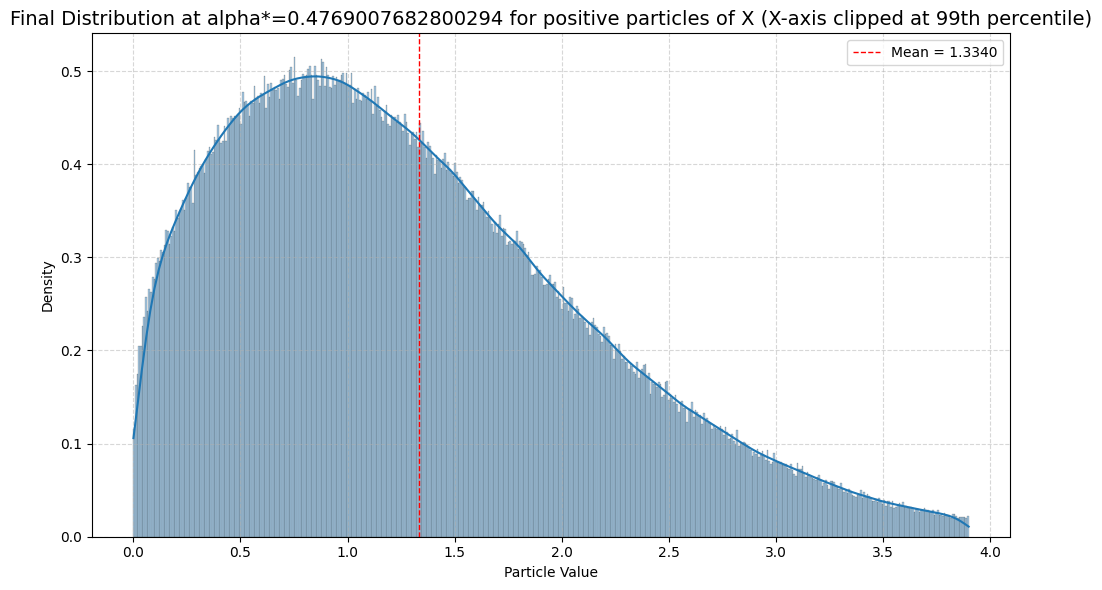

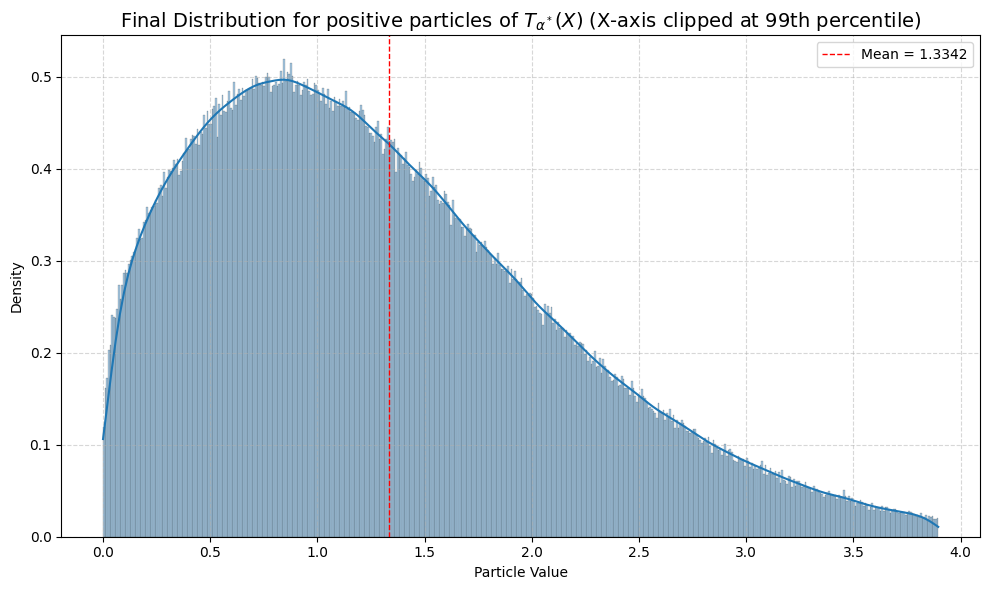

In [10]:
plot_distribution(X_final[X_final != 0], title=f"Final Distribution at alpha*={alpha_star} for positive particles of X", clip_percentile=99, show_bins=True, bins=500)
plot_distribution(T_X_final[T_X_final != 0], title=f"Final Distribution for positive particles of $T_{{\\alpha^*}}(X)$", clip_percentile=99, show_bins=True, bins=500)

##### Robbins-Monro

In [ ]:
def find_alpha_rm(u, v, num_particles=100000, num_iters=20000, initial_alpha=0.4, lrs=None):
    """
    Use Robbins-Monro stochastic approximation.
    """

    if lrs is None:
        # Learning rate schedule parameters
        # c_n = c0 / (n ** gamma)
        c0 = 0.2
        gamma = 0.65 
        lrs = [c0 / (n ** gamma) for n in range(1, num_iters + 1)]
    
    if len(lrs) != num_iters:
        raise ValueError("Length of learning rates must match num_iters.")

    # Initialize the population as a Dirac delta at 1
    X = np.ones(num_particles)
    
    alpha = initial_alpha
    alpha_history = []
    mean_history = []
    
    print(f"Starting Robbins-Monro for u={u}, v={v}")
    print(f"{'Iter':<6} | {'Current Alpha':<15} | {'Step Mean':<15} | {'P(X=0)' :<15}")
    print("-" * 60)
    
    for n in range(1, num_iters + 1):
        Y = apply_T(X, u, v, alpha)
        step_mean = np.mean(Y)
        
        X = Y / step_mean
        
        # If mean > 1, increase alpha, otherwise decrease it.
        alpha = alpha + lrs[n - 1] * (step_mean - 1.0)
        
        # Ensure alpha remains strictly positive
        alpha = max(0.01, alpha)
        
        alpha_history.append(alpha)
        mean_history.append(step_mean)
        
        if n % 2000 == 0:
            print(f"{n:<6d} | {alpha:<15.5f} | {step_mean:<15.5f} | {1-np.count_nonzero(X)/len(X):<15.5f} ")

    # Polyak-Ruppert Averaging: Average the alpha values from the second half of the run
    burn_in = num_iters // 2
    alpha_star_estimate = np.mean(alpha_history[burn_in:])
    
    print("-" * 45)
    print(f"Final alpha: {alpha_history[-1]:.5f}, Polyak-Ruppert Estimate: {alpha_star_estimate:.5f}")
    
    return alpha_star_estimate, X, alpha_history, mean_history

Starting Robbins-Monro for u=0.5, v=0.3
Iter   | Current Alpha   | Step Mean       | P(X=0)         
------------------------------------------------------------
2000   | 0.47526         | 1.00010         | 0.25019         
4000   | 0.47651         | 1.00045         | 0.25007         
6000   | 0.47674         | 1.00113         | 0.24996         
8000   | 0.47688         | 1.00177         | 0.25010         
10000  | 0.47690         | 1.00347         | 0.24992         
12000  | 0.47693         | 0.99809         | 0.25047         
14000  | 0.47694         | 1.00049         | 0.24988         
16000  | 0.47695         | 0.99819         | 0.25050         
18000  | 0.47696         | 1.00112         | 0.24881         
20000  | 0.47695         | 0.99928         | 0.24874         
---------------------------------------------
Final alpha*: 0.47694240328599447
W1 distance between final X and T_alpha(X): 0.002113


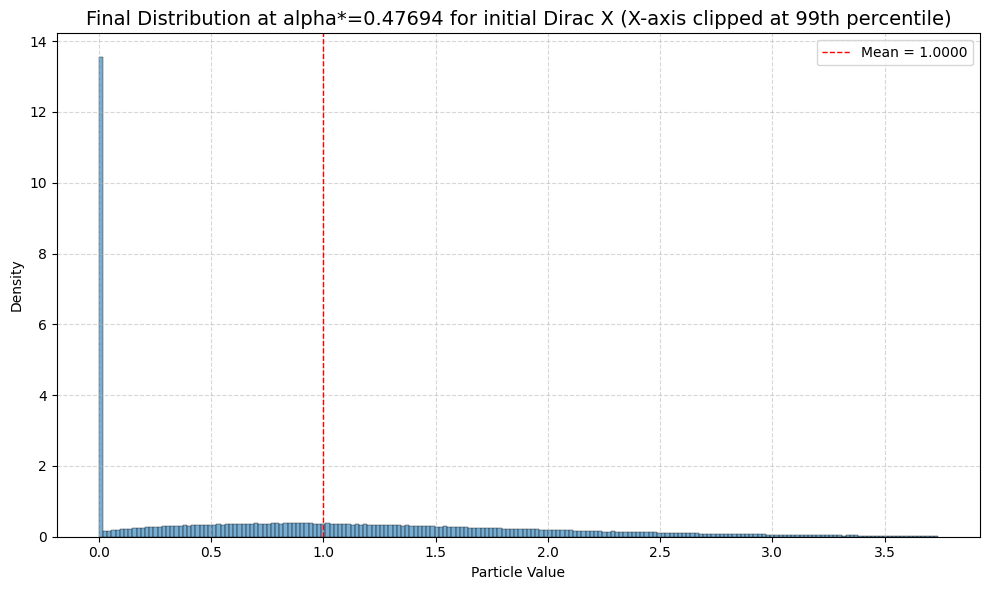

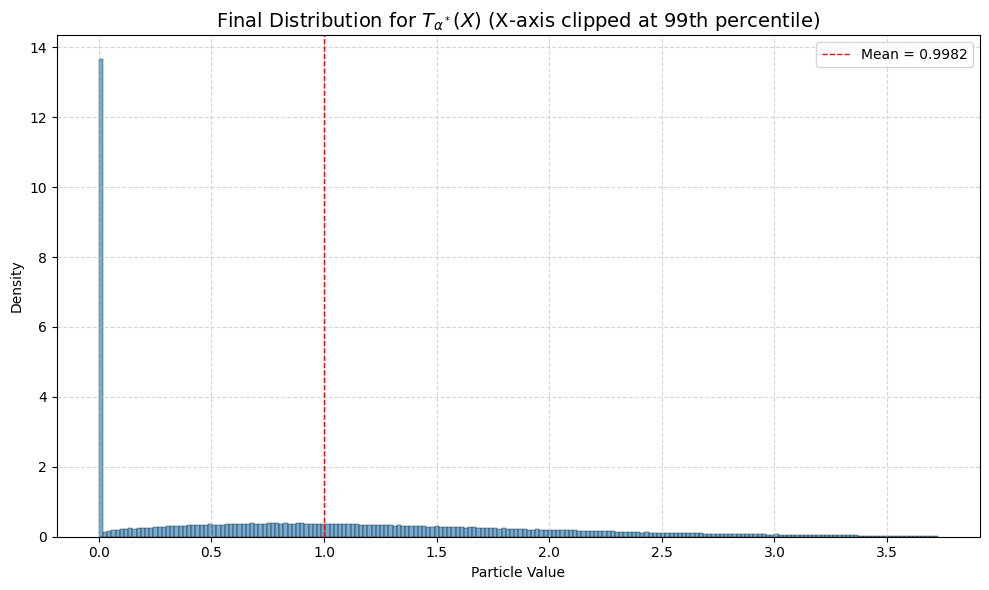

In [ ]:
u = 0.5
v = 0.3
N=1000000
num_iters=20000
lrs = [0.2 / (n ** 0.65) for n in range(1, num_iters + 1)]


alpha, X_final, a_hist, m_hist = find_alpha_rm(u, v, 400000, 20000, initial_alpha=0.3, lrs=lrs)

T_X_final = apply_T(X_final, u, v, alpha)
print(f"W1 distance between final X and T_alpha(X): {wasserstein(X_final, T_X_final):.6f}")

plot_distribution(X_final, title=f"Final Distribution at alpha*={alpha:.5f} for initial Dirac X", clip_percentile=99, show_bins=True, show_kde=False, bins=200)
plot_distribution(T_X_final, title=f"Final Distribution for $T_{{\\alpha^*}}(X)$", clip_percentile=99, show_bins=True, show_kde=False, bins=200)

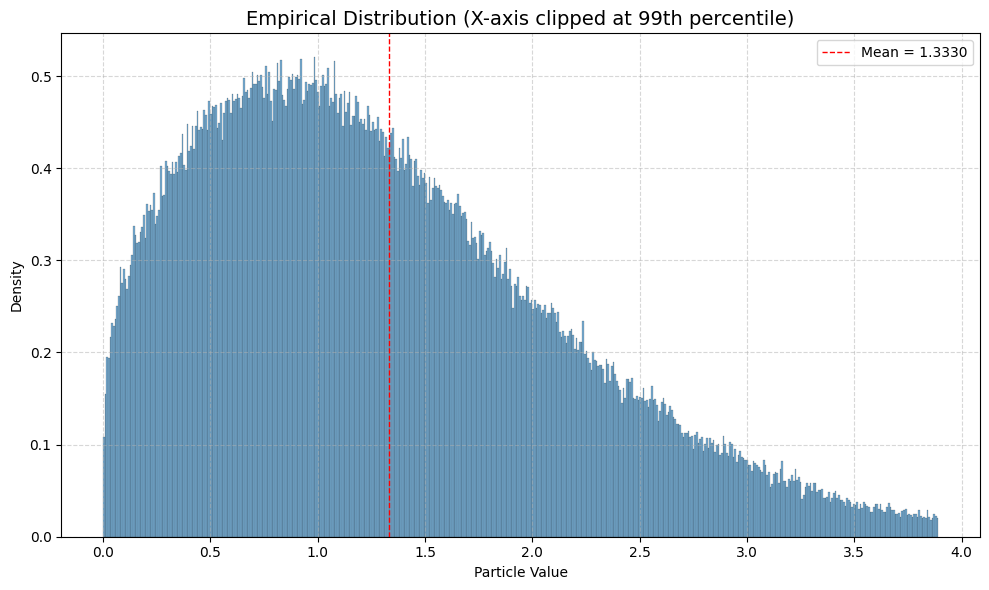

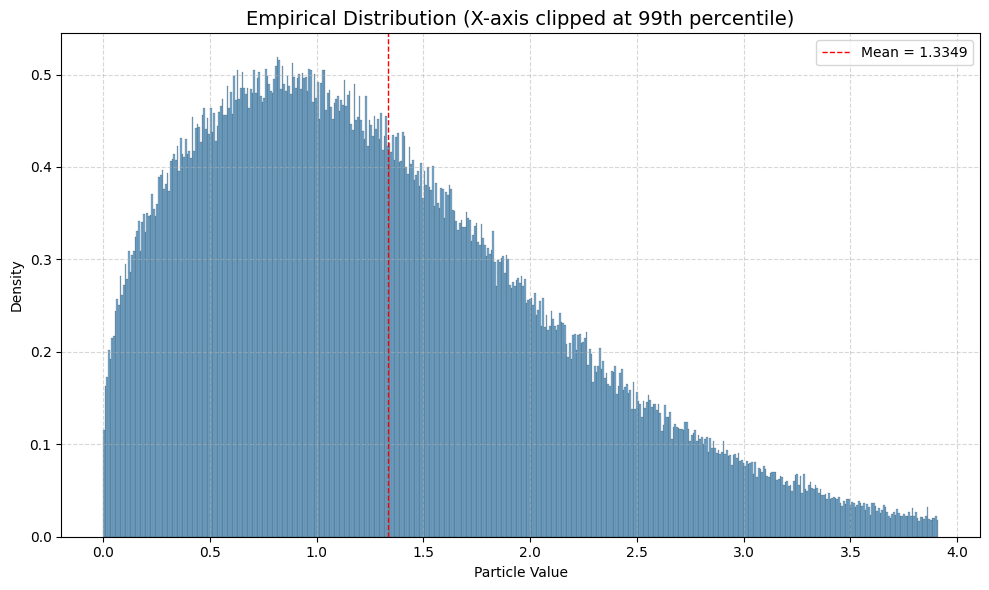

In [8]:
plot_distribution(np.array([x for x in X_final if x > 0]), 
                  clip_percentile=99, show_bins=True, show_kde=False, bins=500)

plot_distribution(np.array([x for x in T_X_final if x > 0]), 
                  clip_percentile=99, show_bins=True, show_kde=False, bins=500)

#### Check if that $\alpha$ may be the true power.

##### Compute distribution of $Y_n$

$$Y_{n+1} = I\left(Y_{U_n}^{(1)} + Y_{n-1-U_n}^{(2)} + 1\right) + J\max\left(Y_{U_n}^{(1)}, Y_{n-1-U_n}^{(2)}\right), \quad Y_0=Y_2=1.$$

Given that the subscripts are for independent copies. The variables $I$ and $J$ are Bernoulli with expectation $u$ and $v$ respectively such that $I+J\le 1$ and $u+v\le 1$, and they are inpependent of all $Y^{(j)}_i$.

In [ ]:
def compute_Yn(max_N, u, v):

    pmfs = [np.array([1.0]), np.array([1.0])]
    cdfs = [np.array([1.0]), np.array([1.0])]
    
    termination_prob = 1.0 - u - v

    for n_target in range(2, max_N + 1):
        if n_target % 10 == 0:
            print(f"Computing up to n={n_target}...")
            
        current_pmf = np.zeros(n_target)

        n = n_target - 1
        
        # U_n is uniform over {0, ..., n-1}
        # Evaluate up to floor(n/2) and double the weights for symmetry
        for k in range((n + 1) // 2):
            j = n - 1 - k
            weight = 2.0 if k != j else 1.0
            
            # Concatenation: convolution
            conv_pmf = np.convolve(pmfs[k], pmfs[j])
            concat_pmf = np.zeros(len(conv_pmf) + 1)

            # Shift by 1 for the "+ 1"
            concat_pmf[1:] = conv_pmf  
            
            length_c = min(len(concat_pmf), n)
            current_pmf[:length_c] += weight * u * concat_pmf[:length_c]
            
            # Alternation
            len_k = len(cdfs[k])
            len_j = len(cdfs[j])
            max_len = max(len_k, len_j)
            
            cdf_k_ext = np.ones(max_len)
            cdf_k_ext[:len_k] = cdfs[k]
            
            cdf_j_ext = np.ones(max_len)
            cdf_j_ext[:len_j] = cdfs[j]
            
            cdf_max = cdf_k_ext * cdf_j_ext
            
            pmf_max = np.zeros(max_len)
            pmf_max[0] = cdf_max[0]
            pmf_max[1:] = cdf_max[1:] - cdf_max[:-1]
            
            length_m = min(len(pmf_max), n)
            current_pmf[:length_m] += weight * v * pmf_max[:length_m]

        # Average over the uniform choice of U_n
        current_pmf /= n
        
        # Termination
        current_pmf[0] += termination_prob
        
        # Correct floating-point inaccuracies
        current_pmf = np.maximum(current_pmf, 0)
        current_pmf /= np.sum(current_pmf)
        
        pmfs.append(current_pmf)
        cdfs.append(np.cumsum(current_pmf))
    
    expectations = [np.sum(pmf * np.arange(len(pmf))) for pmf in pmfs]
        
    return pmfs, cdfs, expectations

In [ ]:
# Costly
pmfs, cdfs, expectations = compute_Yn(max_N=3000, u=0.5, v=0.3)
# plt.plot(expectations[1:]/np.arange(1, len(expectations))**alpha_star)

In [ ]:
# Save computations
cwd = Path.cwd()
candidates = [
    cwd / 'distributions',
    cwd.parent / 'distributions',
    cwd.parent.parent / 'distributions',
]
out_dir = next((p for p in candidates if p.exists()), candidates[1])
out_dir.mkdir(parents=True, exist_ok=True)

# Save pmfs (one file per n)
for n, pmf in enumerate(pmfs):
    fname = out_dir / f'pmf_{n}.txt'
    np.savetxt(fname, pmf, fmt='%.18e')

# Save cdfs (one file per n)
for n, cdf in enumerate(cdfs):
    fname = out_dir / f'cdf_{n}.txt'
    np.savetxt(fname, cdf, fmt='%.18e')

# Save expectations to a single text file
exp_file = out_dir / 'expectations.txt'
with exp_file.open('w') as fh:
    for n, e in enumerate(expectations):
        fh.write(f"{n}	{e:.18e}\n")

print(f'Wrote {len(pmfs)} pmf files, {len(cdfs)} cdf files, and {len(expectations)} expectations to {out_dir}')

Wrote 3001 pmf files, 3001 cdf files, and 3001 expectations to d:\Projects\m2-bezout\internship\src\notebooks\distributions


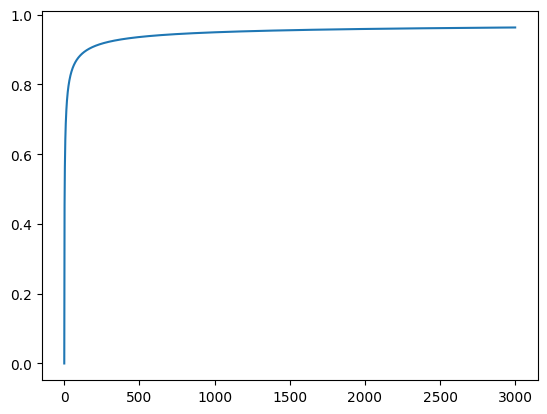

In [63]:
plt.plot(expectations[1:]/np.arange(1, len(expectations))**alpha_star)

#### Check if $T_{\alpha^*}$ has a unique fixed point

Iteration 1000. Mean: 1.26959, Var: 1.46808
Iteration 2000. Mean: 1.53090, Var: 2.15359
Iteration 3000. Mean: 1.60157, Var: 2.34408
Iteration 4000. Mean: 1.64396, Var: 2.46153
Iteration 5000. Mean: 1.93698, Var: 3.38244
Iteration 6000. Mean: 2.05362, Var: 3.84283
Iteration 7000. Mean: 2.42837, Var: 5.30527
Iteration 8000. Mean: 2.57734, Var: 6.00553
Iteration 9000. Mean: 3.02149, Var: 8.28743
Iteration 10000. Mean: 2.78781, Var: 7.07098
Iteration 11000. Mean: 3.10602, Var: 8.83108
Iteration 12000. Mean: 3.46223, Var: 10.78837
Iteration 13000. Mean: 3.86946, Var: 13.66405
Iteration 14000. Mean: 4.25599, Var: 16.19263
Iteration 15000. Mean: 5.46627, Var: 26.82074
Iteration 16000. Mean: 6.42966, Var: 37.36555
Iteration 17000. Mean: 6.63229, Var: 40.20894
Iteration 18000. Mean: 6.92304, Var: 43.74515
Iteration 19000. Mean: 6.77275, Var: 41.71363


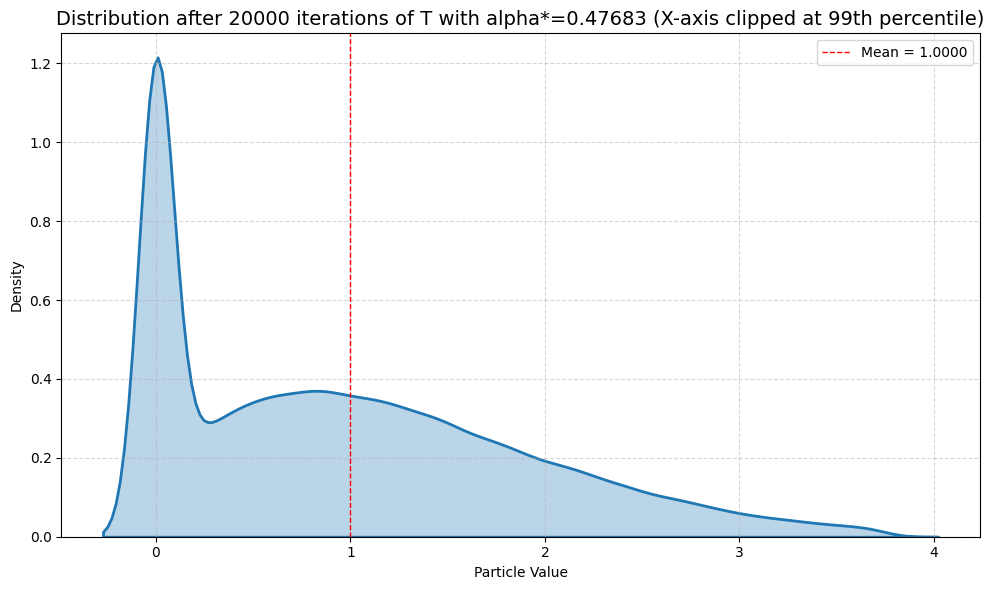

In [ ]:
alpha_star = 0.47725667953491224

generator = MeanOneGenerator(size=100000)
u=0.5
v=0.3
X_init,_,_ = generator.generate_custom_shape('dirac')

X = X_init * 1.36

means = np.zeros(20000)
variances = np.zeros(20000)

means[0] = 1
variances[0] = 0

for i in range(1, 20000):
    X = apply_T(X, u, v, alpha_star)
    means[i] = np.mean(X)
    variances[i] = np.var(X)
    if i % 1000 == 0:
        print(f"Iteration {i}. Mean: {means[i]:.5f}, Var: {variances[i]:.5f}")

plot_distribution(X/np.mean(X), title=f"Distribution after 20000 iterations of T with alpha*={alpha_star:.5f}", clip_percentile=99)

In [10]:
np.all(X_init == 1)

np.True_

#### Check if $S_\alpha = \dfrac{T_\alpha}{\mathbb{E}[T_\alpha]}$ has a fixed point

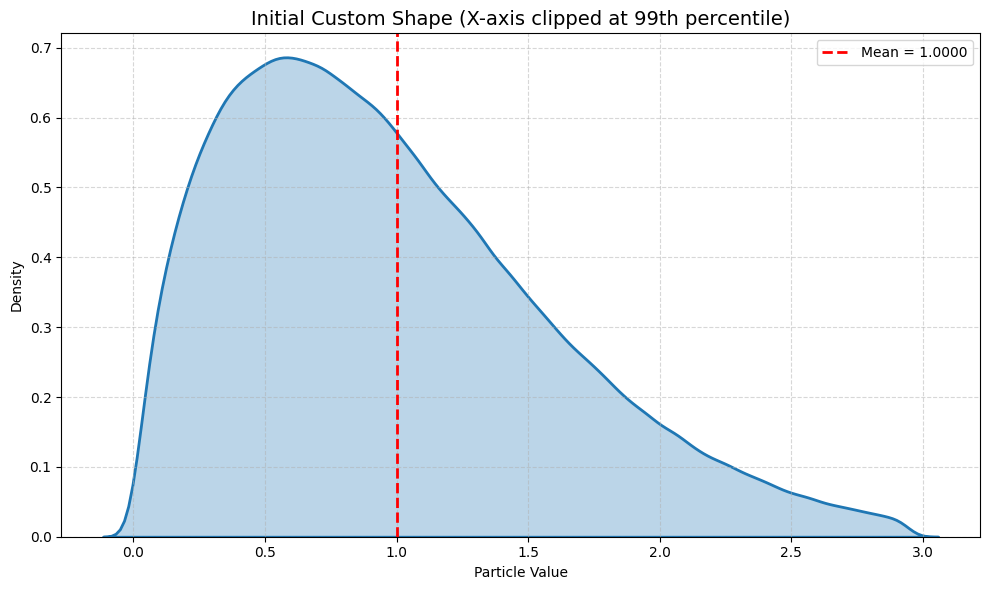

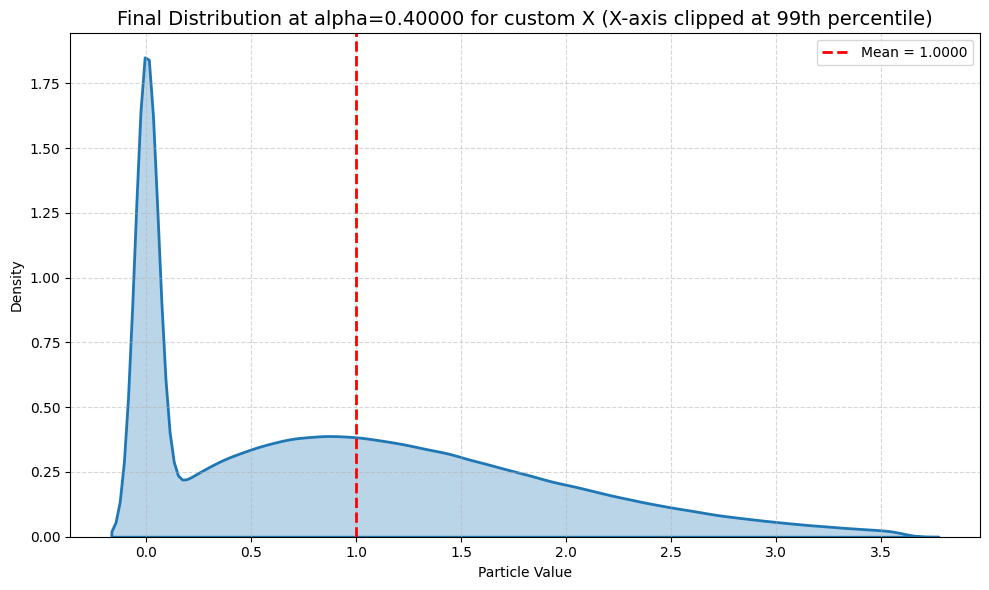

In [24]:
generator = MeanOneGenerator(size=1000000)

X_init,_,_ = generator.generate_custom_shape('weibull_min')
plot_distribution(X_init, title="Initial Custom Shape", clip_percentile=99)

alpha = 0.4
u, v = 0.5, 0.3

X = X_init

for _ in range(20):
    X = apply_S(X, u, v, alpha)

plot_distribution(X, title=f"Final Distribution at alpha={alpha:.5f} for custom X", clip_percentile=99)

In [ ]:
Y_init,_,_ = generator.generate_uniform_shape()
plot_distribution(Y_init, title="Initial Uniform Shape", clip_percentile=99)

Y = Y_init

for _ in range(20):
    Y = apply_S(Y, u, v, alpha)

plot_distribution(Y, title=f"Final Distribution at alpha={alpha:.5f} for uniform Y", clip_percentile=99)

#### Check if $S_\alpha$ is a contraction in the $W_1$ metric.

In [ ]:
u=0.5
v=0.3
alpha=0.4

generator = MeanOneGenerator(size=1000000)
X,_,_ = generator.generate_uniform_shape()
Y,_,_ = generator.generate_custom_shape("lognorm")

plot_distribution(X, title="Initial Uniform Shape", clip_percentile=99)
plot_distribution(Y, title="Initial Lognorm Shape", clip_percentile=99)

print(f"Wp-Contraction of S_alpha (alpha={alpha}, u={u}, v={v})")
print("-" * 75)
print(f"{'Generation':<15} | {'Distance W_s(X, Y)':<25} | {'Contraction Ratio':<20}")
print("-" * 75)

for i in range(1, 30):
    
    current_dist = wasserstein(X, Y)
    
    X_next = apply_S(X, u, v, alpha)
    Y_next = apply_S(Y, u, v, alpha)
    
    next_dist = wasserstein(X_next, Y_next, p=1)
    
    ratio = next_dist / current_dist
    
    print(f"Gen {i-1:02d} -> {i:02d}  | {current_dist:<25.6f} | {ratio:<20.6f}")
    
    X, Y = X_next, Y_next

$X_n = I\left(\left(\dfrac{U_n}{n}\right)^\alpha X_{U_n} + \left(\dfrac{n-1-U_n}{n}\right)^\alpha X_{n-1-U_n} + \dfrac{1}{n^\alpha}\right) + J\max\left(\left(\dfrac{U_n}{n}\right)^\alpha X_{U_n}, \left(\dfrac{n-1-U_n}{n}\right)^\alpha X_{n-1-U_n}\right)$

Here $I,J$ are mutually exclusive Bernoulli and $U_n$ is uniform over $\{0,\ldots,n-1\}$. Let $X_0=X_1=0$. 

The paramemter $\alpha$ is chosen such that the fixed-point equation
$$X \stackrel{d}{=} I(U^\alpha X^{(1)} + (1-U)^{\alpha} X^{(2)}) + J\max(U^\alpha X^{(1)}, (1-U)^{\alpha} X^{(2)})$$

has a unique mean-1 solution $X$. Here $X^{(1)}$ and $X^{(2)}$ are iid copies of $X$ and $U$ is uniform over $[0,1]$.

In [6]:
def pmf_to_particles(pmf_array, size):
    """
    Converts a PMF array into a corresponding array of particles.
    """
    possible_values = np.arange(len(pmf_array))
    normalized_pmf = pmf_array / np.sum(pmf_array)
    
    particles = np.random.choice(possible_values, size=size, p=normalized_pmf)
    
    return particles

Normalizing constant: 0.9650694670847761


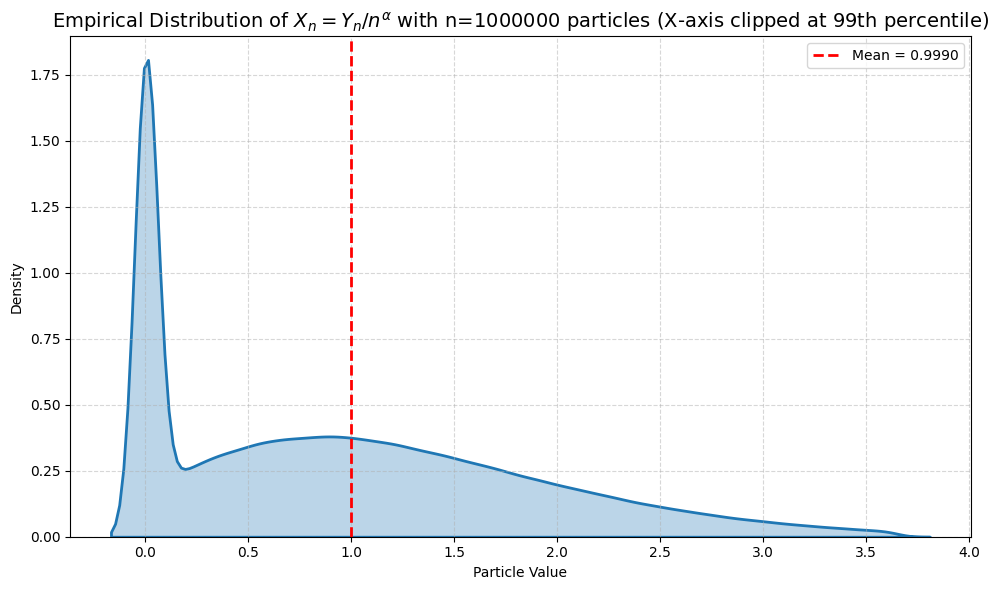

In [9]:
n = 3000
N = 1000000

out_dir = Path.cwd() / 'distributions'
pmf_file = out_dir / f'pmf_{n}.txt'

Yn_pmf = np.loadtxt(pmf_file)
EY_n = np.sum(np.arange(len(Yn_pmf)) * Yn_pmf)

alpha_star = 0.47683267565444126
normalizing_constant = EY_n/(n ** alpha_star)
print("Normalizing constant:", normalizing_constant)

Yn = pmf_to_particles(Yn_pmf, size=N)
Xn = Yn / (n ** alpha_star * normalizing_constant)

plot_distribution(Xn, title=f"Empirical Distribution of $X_n = Y_n / n^\\alpha$ with n={N} particles", 
                  bins=100, clip_percentile=99, show_kde=True)

#### Check if contraction method works

In [ ]:
import scipy.integrate as integrate

def compute_H(p, u, v, alpha):
    """
    Computes the contraction function H(p, alpha) for a given p.
    
    Parameters:
    p (float): The Wasserstein parameter / power.
    u (float): Probability of the sum operation (I).
    v (float): Probability of the max operation (J).
    alpha (float): The scaling exponent.
    
    Returns:
    float: The evaluated value of H(p, alpha).
    """
    # 1. Define the integrand: (x^alpha + (1-x)^alpha)^p
    def integrand(x):
        return (x**alpha + (1 - x)**alpha)**p
    
    # 2. Compute the integral from 0 to 1
    # quad returns a tuple: (value_of_integral, estimate_of_absolute_error)
    integral_value, error_estimate = integrate.quad(integrand, 0, 1, epsrel=1e-12)
    
    # 3. Add the maximum term component
    max_term = (2 * v) / (alpha * p + 1)
    
    # 4. Combine for the final result
    H_value = u * integral_value + max_term
    
    return H_value


u = 0.5
v = 0.3

lower = 0
upper = 1

alpha = 0.5
p=1

print(f"Iteration | alpha | H(p={p}, alpha)")

for _ in range(20):
    mid = (lower + upper) / 2
    H_mid = compute_H(p, u, v, mid)

    if H_mid < 1:
        upper = mid
    else:        
        lower = mid

    print(f"{_+1:9d} | {mid:.6f} | {H_mid:.6f}")

    alpha = mid



Iteration | alpha | H(p=1, alpha)
        1 | 0.500000 | 1.066667
        2 | 0.750000 | 0.914286
        3 | 0.625000 | 0.984615
        4 | 0.562500 | 1.024000
        5 | 0.593750 | 1.003922
        6 | 0.609375 | 0.994175
        7 | 0.601562 | 0.999024
        8 | 0.597656 | 1.001467
        9 | 0.599609 | 1.000244
       10 | 0.600586 | 0.999634
       11 | 0.600098 | 0.999939
       12 | 0.599854 | 1.000092
       13 | 0.599976 | 1.000015
       14 | 0.600037 | 0.999977
       15 | 0.600006 | 0.999996
       16 | 0.599991 | 1.000006
       17 | 0.599998 | 1.000001
       18 | 0.600002 | 0.999999
       19 | 0.600000 | 1.000000
       20 | 0.599999 | 1.000000


#### Simpler case: there is only sum or max

In [28]:
def apply_T(X, alpha, times=1, type:Literal["sum", "max"]="sum"):

    Y = X

    for _ in range(times):
      # Sample independent pairs
      Y1 = sample_from_empirical(Y)
      Y2 = sample_from_empirical(Y)
      
      # Sample U
      U = np.random.uniform(0, 1, size=len(Y))

      # Apply the operator T_alpha
      term1 = (U**alpha) * Y1
      term2 = ((1 - U)**alpha) * Y2

      if type == "sum":
          sum = term1 + term2
      else:
          sum = np.maximum(term1, term2)

    return sum

def apply_S(X, alpha, times=1, type:Literal["sum", "max"]="sum"):

    Y = X

    for _ in range(times):
      # Sample independent pairs
      Y1 = sample_from_empirical(Y)
      Y2 = sample_from_empirical(Y)
      
      # Sample U
      U = np.random.uniform(0, 1, size=len(Y))

      # Apply the operator S_alpha
      term1 = (U**alpha) * Y1
      term2 = ((1 - U)**alpha) * Y2

      if type == "sum":
          sum = term1 + term2
      else:
          sum = np.maximum(term1, term2)

      Y = sum - np.mean(sum) + 1

    return Y

def apply_S_for_pair(X, Y, alpha, times, type:Literal["sum", "max"]="sum"):
    for _ in range(times):
        X = apply_S(X, alpha, times=1, type=type)
        Y = apply_S(Y, alpha, times=1, type=type)

        print(f"After iteration {_+1}: W1 distance = {wasserstein(X, Y):.6f}")

    return X, Y

In [ ]:
generator = MeanOneGenerator(size=5000000)
alpha = 0.5

X = generator.generate_custom_shape('uniform')[0]
S_X = apply_S(X, alpha, times=1, type="sum")

for i in range(300):
  S_X = apply_S(X, alpha, times=1, type="sum")
  if (i + 1) % 10 == 0:
    print(f"Iteration {i+1}: W1(X, S_alpha(X))={wasserstein(X, S_X):.6f}")
  X = S_X

In [29]:
generator = MeanOneGenerator(size=5000000)
alpha = 0.5

X = generator.generate_custom_shape('uniform')[0]
S_X = apply_S(X, alpha, times=1, type="max")

for i in range(100):
  S_X = apply_S(X, alpha, times=1, type="max")
  if (i + 1) % 10 == 0:
    print(f"Iteration {i+1}: W1(X, S_alpha(X))={wasserstein(X, S_X):.6f}")
  X = S_X

Iteration 10: W1(X, S_alpha(X))=0.002557
Iteration 20: W1(X, S_alpha(X))=0.000144
Iteration 30: W1(X, S_alpha(X))=0.000071
Iteration 40: W1(X, S_alpha(X))=0.000074
Iteration 50: W1(X, S_alpha(X))=0.000097
Iteration 60: W1(X, S_alpha(X))=0.000063
Iteration 70: W1(X, S_alpha(X))=0.000091
Iteration 80: W1(X, S_alpha(X))=0.000118
Iteration 90: W1(X, S_alpha(X))=0.000103
Iteration 100: W1(X, S_alpha(X))=0.000080


In [65]:
generator = MeanOneGenerator(size=2000000)
X = generator.generate_uniform_shape(width=0.5)[0]

for i in range(400):
    X = apply_S(X, alpha=0.2, times=1, type="max")
    if (i + 1) % 20 == 0:
      print(f"Iteration {i + 1}: Variance: {variance(X):.6f}")

# plot_distribution(X, title=f"Final Distribution for S_alpha with alpha=0.5 (type=max)", clip_percentile=99)

Iteration 20: Variance: 0.011659
Iteration 40: Variance: 0.012328
Iteration 60: Variance: 0.012827
Iteration 80: Variance: 0.012902
Iteration 100: Variance: 0.013138
Iteration 120: Variance: 0.013117
Iteration 140: Variance: 0.013181
Iteration 160: Variance: 0.013458
Iteration 180: Variance: 0.013530
Iteration 200: Variance: 0.013382
Iteration 220: Variance: 0.013232
Iteration 240: Variance: 0.013313
Iteration 260: Variance: 0.013616
Iteration 280: Variance: 0.013782
Iteration 300: Variance: 0.013564
Iteration 320: Variance: 0.013197
Iteration 340: Variance: 0.013226
Iteration 360: Variance: 0.013494
Iteration 380: Variance: 0.013374
Iteration 400: Variance: 0.013392


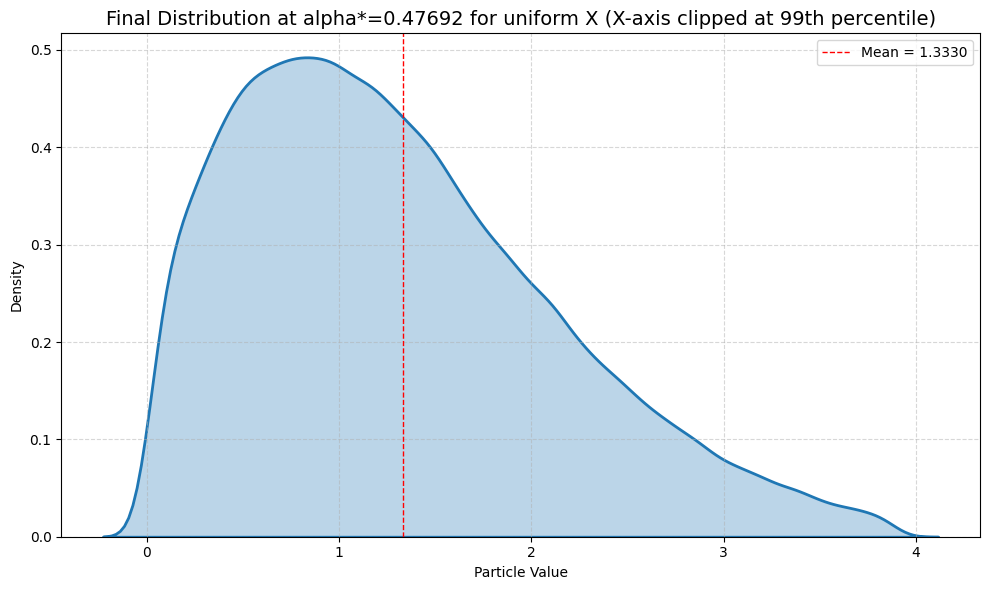

In [ ]:
plot_distribution(np.array([x for x in X_final if x > 0]), title=f"Final Distribution at alpha*={alpha:.5f} for uniform X", clip_percentile=99, show_bins=True, show_kde=False, bins=1000)

In [64]:
np.isfinite(X_final)

array([ True,  True,  True, ...,  True,  True,  True])

In [65]:
X_final

array([0.        , 0.61348757, 2.33516386, ..., 0.17339038, 0.2979789 ,
       0.12687958])

In [69]:
len([x for x in X_final if x == 0])/len(X_final)

0.24982

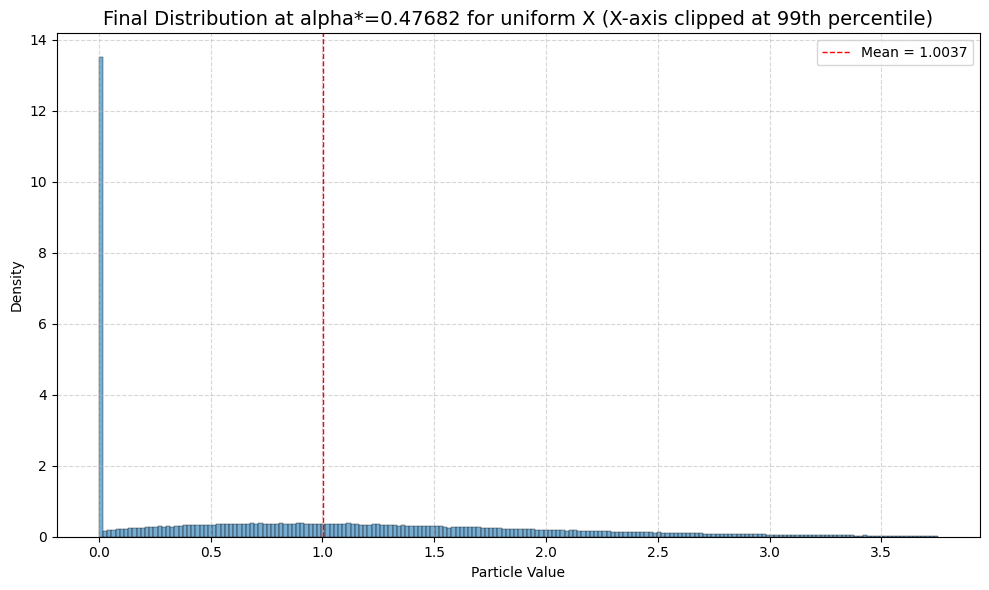

In [38]:
plot_distribution(T_X_final, title=f"Final Distribution at alpha*={alpha:.5f} for uniform X", clip_percentile=99, show_bins=True, show_kde=False, bins=200)